In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [185]:
df=pd.read_csv('/Users/zoetankersley/sunrise_social_club/data/processed/sales_merged.csv')

In [186]:
df.head()

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location
0,2026-07-08,12:48:27,Cold Brew,Cold Brew,Whole Milk,False,1.0,8.0,16oz,True,Coconut,80.0,Partly Cloudy,Market,Nags Head
1,2026-07-08,12:48:27,Aaron,Lemonade,Lemonade,True,1.0,5.0,16oz,False,"Strawberry, Blueberry",80.0,Partly Cloudy,Market,Nags Head
2,2026-07-08,12:42:19,Lemonade,Lemonade,Lemonade,False,1.0,5.0,16oz,False,Strawberry,80.0,Partly Cloudy,Market,Nags Head
3,2026-07-08,12:41:33,Lemonade,Lemonade,Lemonade,False,1.0,5.0,16oz,False,Blueberry,80.0,Partly Cloudy,Market,Nags Head
4,2026-07-08,12:40:38,Lemonade,Lemonade,Lemonade,False,1.0,5.0,16oz,False,Strawberry,80.0,Partly Cloudy,Market,Nags Head


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2220 entries, 0 to 2219
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2220 non-null   object 
 1   Time               2220 non-null   object 
 2   Original_Item      2220 non-null   object 
 3   Item               2220 non-null   object 
 4   Base               1769 non-null   object 
 5   Signature_Drink    2220 non-null   bool   
 6   Qty                2220 non-null   float64
 7   Net_Sales          2220 non-null   float64
 8   Size               1898 non-null   object 
 9   Cold_Foam          2220 non-null   bool   
 10  Flavor             1813 non-null   object 
 11  Avg_Temp           2220 non-null   float64
 12  Weather_Condition  2220 non-null   object 
 13  Event_Type         2220 non-null   object 
 14  Location           2220 non-null   object 
dtypes: bool(2), float64(3), object(10)
memory usage: 229.9+ KB


In [188]:
df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte    8335.42
Cold Brew       5895.00
Lemonade        2052.00
Sticker          328.00
Mug              150.00
Name: Net_Sales, dtype: float64

In [189]:
df.groupby("Flavor")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Flavor
Strawberry               4897.58
Blueberry                2404.00
Salted Maple             2291.66
Vanilla                  1350.00
Banana                   1300.00
Cinn Roll                 868.00
Coconut                   684.00
Strawberry, Blueberry     417.00
Cake Batter               224.00
Horchata                  144.00
Name: Net_Sales, dtype: float64

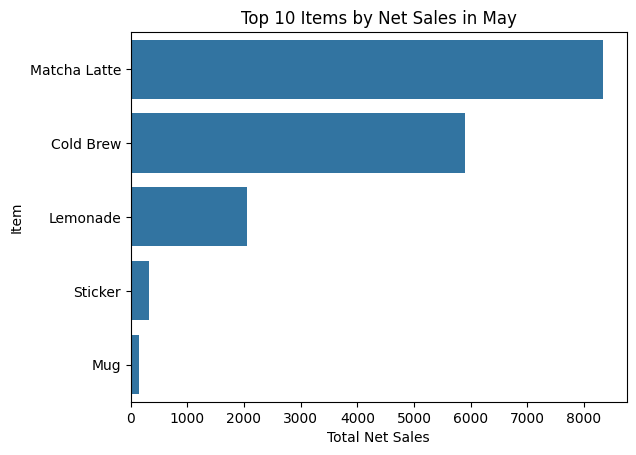

In [190]:
sns.barplot(x=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).values, y=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).index)
plt.xlabel("Total Net Sales")
plt.ylabel("Item")
plt.title("Top 10 Items by Net Sales in May")
plt.show()

In [191]:
df.groupby("Item")["Qty"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte    1015.0
Cold Brew        808.0
Lemonade         475.0
Sticker          165.0
Mug                2.0
Name: Qty, dtype: float64

In [192]:
df.groupby("Event_Type")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Event_Type
Market    15389.42
Popup      1371.00
Name: Net_Sales, dtype: float64

In [193]:
df["Cold_Foam"].value_counts()

Cold_Foam
True     1165
False    1055
Name: count, dtype: int64

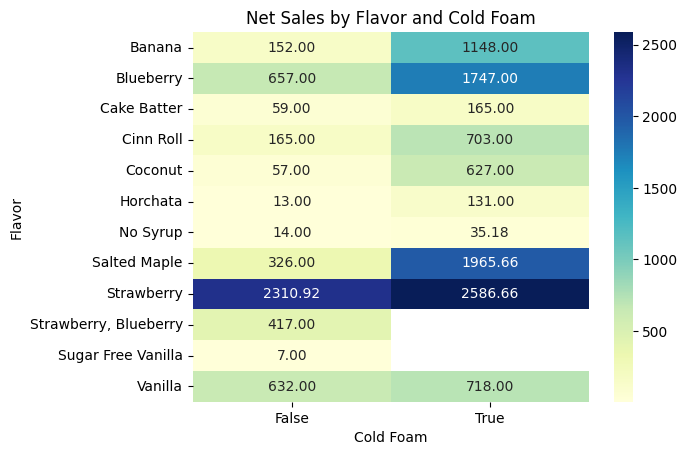

In [194]:
pivot = df.pivot_table(
    index="Flavor",
    columns="Cold_Foam",
    values="Net_Sales",
    aggfunc="sum"
)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Net Sales by Flavor and Cold Foam")
plt.xlabel("Cold Foam")
plt.ylabel("Flavor")
plt.show()

In [195]:
df["Flavor"].value_counts()

Flavor
Strawberry               612
Blueberry                296
Salted Maple             277
Vanilla                  163
Banana                   151
Cinn Roll                104
Strawberry, Blueberry     83
Coconut                   81
Cake Batter               23
Horchata                  15
No Syrup                   7
Sugar Free Vanilla         1
Name: count, dtype: int64

In [196]:
df.groupby("Item")["Net_Sales"].sum() / df.groupby("Item")["Qty"].sum()

Item
Cold Brew        7.295792
Lemonade         4.320000
Matcha Latte     8.212236
Mug             75.000000
Sticker          1.987879
dtype: float64

In [197]:
pd.crosstab(df["Flavor"], df["Cold_Foam"])

Cold_Foam,False,True
Flavor,,
Banana,21,130
Blueberry,97,199
Cake Batter,5,18
Cinn Roll,23,81
Coconut,8,73
Horchata,2,13
No Syrup,2,5
Salted Maple,44,233
Strawberry,335,277


In [198]:
df["Base"].value_counts()

Base
Whole Milk    744
Lemonade      502
Oat Milk      497
No Milk        26
Name: count, dtype: int64

In [199]:
df.groupby("Base")["Net_Sales"].sum()

Base
Lemonade      2788.18
No Milk        194.00
Oat Milk      4172.00
Whole Milk    6500.58
Name: Net_Sales, dtype: float64

In [200]:
pd.crosstab(df["Item"], df["Base"])

Base,Lemonade,No Milk,Oat Milk,Whole Milk
Item,,,,
Cold Brew,0,26,187,376
Lemonade,409,0,0,0
Matcha Latte,93,0,310,368


In [201]:
df.groupby("Item")["Avg_Temp"].mean()

Item
Cold Brew       81.055331
Lemonade        81.466993
Matcha Latte    80.910352
Mug             75.000000
Sticker         80.488550
Name: Avg_Temp, dtype: float64

In [202]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

/var/folders/w2/4nk24xz14yg09dbpyrxdn4c80000gn/T/ipykernel_73945/816105062.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


In [203]:
df.groupby("Hour")["Net_Sales"].sum()

Hour
6      202.00
7       95.00
8      236.00
9     5099.00
10    4513.00
11    4045.42
12    2247.00
13     250.00
14      73.00
Name: Net_Sales, dtype: float64

In [204]:
pd.crosstab(df["Hour"], df["Item"])

Item,Cold Brew,Lemonade,Matcha Latte,Mug,Sticker
Hour,,,,,
6,12,2,13,0,2
7,5,1,7,0,0
8,9,2,16,0,0
9,263,74,276,0,42
10,235,125,216,0,32
11,151,127,230,1,34
12,64,66,153,1,18
13,2,10,19,0,3
14,0,2,7,0,0


In [205]:
df.groupby(
    ["Item","Base","Flavor","Cold_Foam"]
)["Net_Sales"].sum().sort_values(ascending=False)

Item          Base        Flavor        Cold_Foam
Matcha Latte  Whole Milk  Strawberry    True         1298.66
Cold Brew     Whole Milk  Salted Maple  True          968.00
Lemonade      Lemonade    Strawberry    False         882.00
Matcha Latte  Oat Milk    Strawberry    True          795.00
              Lemonade    Strawberry    False         708.00
                                                      ...   
Cold Brew     Oat Milk    No Syrup      True            7.00
              No Milk     Salted Maple  False           7.00
                          Cinn Roll     True            7.00
Lemonade      Lemonade    Blueberry     True            6.00
                          Coconut       True            6.00
Name: Net_Sales, Length: 82, dtype: float64

In [206]:
df.groupby(
    ["Item","Base","Flavor","Cold_Foam"]
)["Qty"].sum().sort_values(ascending=False).head(20)

Item          Base        Flavor                 Cold_Foam
Lemonade      Lemonade    Strawberry             False        190.0
Matcha Latte  Whole Milk  Strawberry             True         150.0
Cold Brew     Whole Milk  Salted Maple           True         124.0
Matcha Latte  Lemonade    Strawberry             False         93.0
              Oat Milk    Strawberry             True          92.0
Lemonade      Lemonade    Strawberry, Blueberry  False         91.0
Cold Brew     Whole Milk  Banana                 True          68.0
Matcha Latte  Whole Milk  Blueberry              True          57.0
Cold Brew     Whole Milk  Blueberry              True          53.0
              Oat Milk    Salted Maple           True          50.0
Lemonade      Lemonade    Blueberry              False         47.0
Matcha Latte  Oat Milk    Blueberry              True          43.0
Cold Brew     Whole Milk  Vanilla                True          37.0
Matcha Latte  Oat Milk    Strawberry             False   

In [207]:
pd.crosstab(
    [df["Item"], df["Base"], df["Flavor"], df["Cold_Foam"]],
    df["Event_Type"],
    values=df["Net_Sales"],
    aggfunc="sum"
)

Event_Type                                       Market  Popup
Item         Base       Flavor       Cold_Foam                
Cold Brew    No Milk    Banana       True          8.00    NaN
                        Blueberry    True         63.00    NaN
                        Cinn Roll    True          7.00    NaN
                        Salted Maple False         7.00    NaN
                                     True         30.00    NaN
...                                                 ...    ...
Matcha Latte Whole Milk Salted Maple True        171.00    9.0
                        Strawberry   False       140.92   92.0
                                     True       1205.66   93.0
                        Vanilla      False       133.00    7.0
                                     True        150.00    9.0

[82 rows x 2 columns]

In [208]:
df.isna().sum()

Date                   0
Time                   0
Original_Item          0
Item                   0
Base                 451
Signature_Drink        0
Qty                    0
Net_Sales              0
Size                 322
Cold_Foam              0
Flavor               407
Avg_Temp               0
Weather_Condition      0
Event_Type             0
Location               0
Hour                   0
dtype: int64

In [209]:
df[df['Base'].isna()]['Item'].value_counts()

Item
Matcha Latte    166
Cold Brew       152
Sticker         131
Mug               2
Name: count, dtype: int64

In [210]:
df[(df['Base'].isna()) & (df['Item'] == 'Matcha Latte')]

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location,Hour
287,2026-07-07,09:53:22,Matcha Latte,Matcha Latte,NaN,False,1.0,7.0,16oz,False,NaN,88.0,Partly Cloudy,Market,Kill Devil Hills,9
566,2026-06-30,11:19:09,Matcha Latte,Matcha Latte,NaN,False,1.0,8.0,16oz,False,Blueberry,77.0,Sunny,Market,Kill Devil Hills,11
601,2026-06-30,10:32:37,Matcha Latte,Matcha Latte,NaN,False,1.0,7.0,16oz,False,NaN,77.0,Sunny,Market,Kill Devil Hills,10
609,2026-06-30,10:23:08,Matcha Latte,Matcha Latte,NaN,False,1.0,9.0,16oz,True,Strawberry,77.0,Sunny,Market,Kill Devil Hills,10
755,2026-06-27,11:34:50,Matcha Latte,Matcha Latte,NaN,False,2.0,14.0,12oz,False,Blueberry,80.0,Rainy,Market,Manteo,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2190,2026-05-23,09:40:00,Matcha Latte,Matcha Latte,NaN,False,2.0,16.0,12oz,True,NaN,77.0,Partly Cloudy,Popup,Kill Devil Hills,9
2191,2026-05-23,09:38:39,Matcha Latte,Matcha Latte,NaN,False,1.0,9.0,16oz,True,Strawberry,77.0,Partly Cloudy,Popup,Kill Devil Hills,9
2196,2026-05-23,09:35:07,Matcha Latte,Matcha Latte,NaN,False,2.0,14.0,12oz,False,NaN,77.0,Partly Cloudy,Popup,Kill Devil Hills,9
2203,2026-05-23,09:28:24,Matcha Latte,Matcha Latte,NaN,False,2.0,14.0,12oz,False,NaN,77.0,Partly Cloudy,Popup,Kill Devil Hills,9


In [211]:
order_level = df.groupby(["Date", "Time"])["Net_Sales"].sum()
order_level.describe()

count    1466.000000
mean       11.432756
std         6.515691
min         2.000000
25%         8.000000
50%         9.000000
75%        15.000000
max        93.000000
Name: Net_Sales, dtype: float64

In [212]:
recent=df[df["Date"]>="2026-06-20"]

In [213]:
recent.groupby('Item')['Qty'].sum()

Item
Cold Brew       543.0
Lemonade        263.0
Matcha Latte    522.0
Sticker          88.0
Name: Qty, dtype: float64